[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


The Project Gutenberg eBook of Alice s Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri 
---
The Project Gutenberg eBook of Through the Looking Glass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions  
---
The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever  
---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'rac

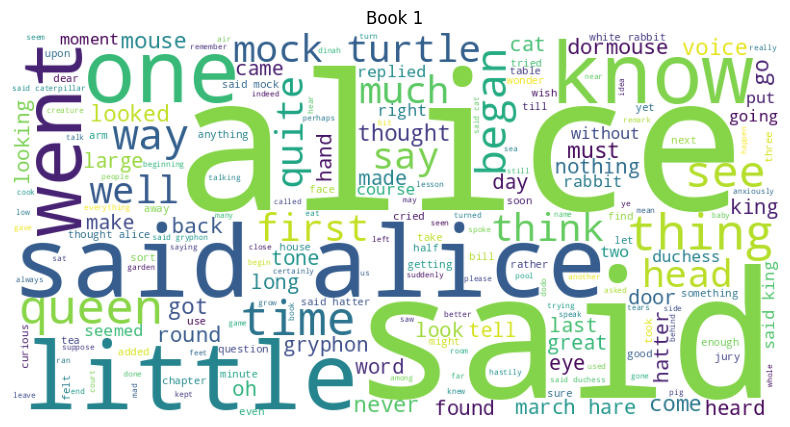

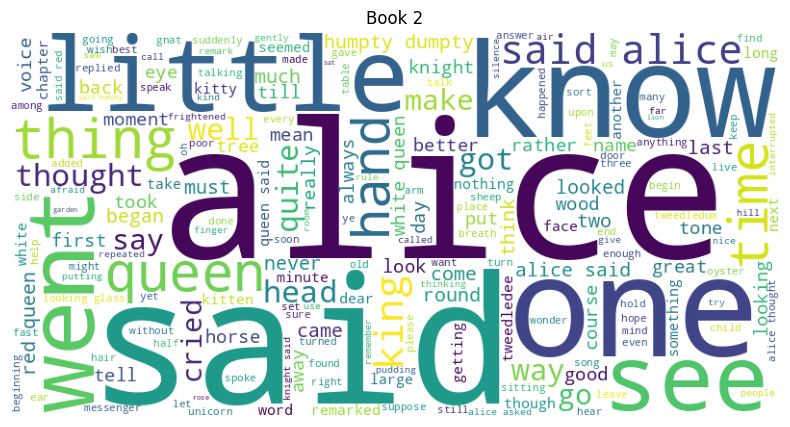

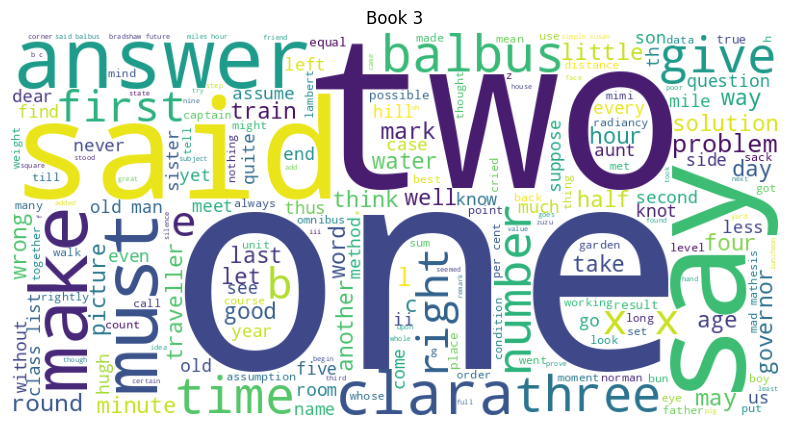

Top 5 (BoW): [('say', np.int64(114)), ('alice', np.int64(103)), ('go', np.int64(68)), ('one', np.int64(65)), ('get', np.int64(57))]
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2484 stored elements and shape (3, 1792)>
  Coords	Values
  (0, 1483)	2
  (0, 1207)	1
  (0, 680)	1
  (0, 455)	1
  (0, 36)	57
  (0, 17)	1
  (0, 1761)	2
  (0, 766)	1
  (0, 16)	1
  (0, 884)	1
  (0, 223)	1
  (0, 977)	1
  (0, 617)	1
  (0, 459)	1
  (0, 307)	1
  (0, 246)	15
  (0, 1241)	15
  (0, 730)	5
  (0, 763)	2
  (0, 1177)	9
  (0, 1558)	1
  (0, 764)	2
  (0, 232)	2
  (0, 1242)	2
  (0, 914)	10
  :	:
  (2, 1505)	1
  (2, 595)	1
  (2, 1318)	1
  (2, 558)	1
  (2, 147)	1
  (2, 1049)	1
  (2, 533)	1
  (2, 759)	1
  (2, 296)	1
  (2, 1492)	1
  (2, 1661)	1
  (2, 1343)	1
  (2, 1293)	1
  (2, 547)	1
  (2, 659)	1
  (2, 1334)	1
  (2, 323)	1
  (2, 48)	1
  (2, 1728)	1
  (2, 227)	1
  (2, 1153)	1
  (2, 849)	1
  (2, 912)	1
  (2, 303)	1
  (2, 852)	1


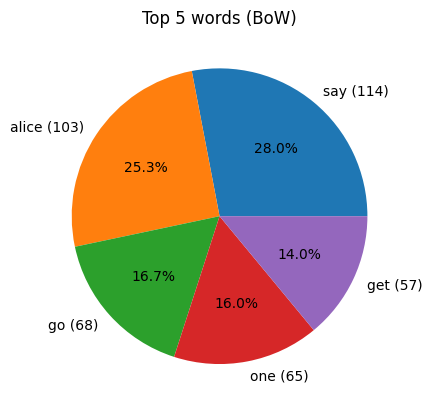

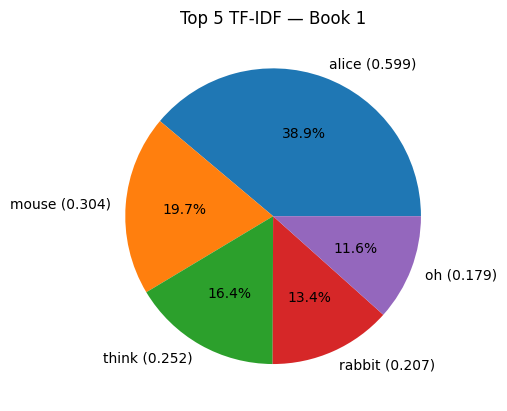

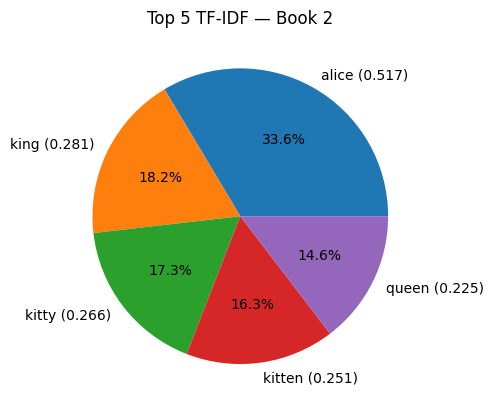

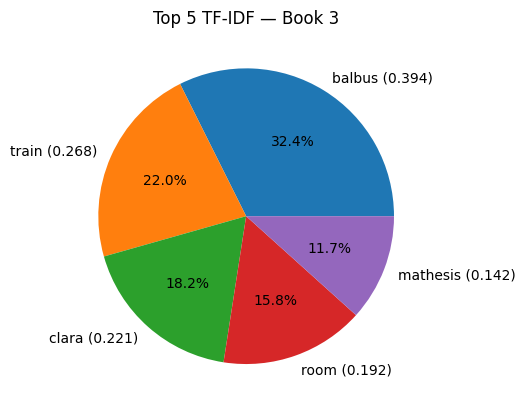

In [1]:
import re
import requests
import nltk
import spacy
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt'); nltk.download('punkt_tab')
nltk.download('stopwords'); nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab'); nltk.download('words')
nlp = spacy.load('en_core_web_sm')

urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt",
]

# 1. Load + clean
def load_texts(urls):
    corpus = []
    for url in urls:
        text = requests.get(url).text
        text = re.sub(r'[^A-Za-z\s]', ' ', text)   # keep words only
        text = re.sub(r'\s+', ' ', text).strip()
        corpus.append(text)
    return corpus

corpus = load_texts(urls)

# 2. First 200 chars + strip Gutenberg header/footer
for t in corpus:
    print(t[:200], '\n---')

def trim(t):
    start = t.find(' START')
    end   = t.find(' END')
    return t[start:end] if start != -1 and end != -1 else t

corpus = [trim(t) for t in corpus]

# 3. Tokenize
tokens_list = [word_tokenize(t.lower()) for t in corpus]
for tok in tokens_list:
    print(tok[:150], '\n---')

# 4. Remove stopwords
stop = set(stopwords.words('english'))
clean_tokens = [[w for w in toks if w not in stop] for toks in tokens_list]
for ct in clean_tokens:
    print('me count:', ct.count('me'), '| my count:', ct.count('my'))  # ~0

# 5. Stemming
ps = PorterStemmer()
stemmed = [[ps.stem(w) for w in ct] for ct in clean_tokens]
for s in stemmed:
    print(s[:50], '\n---')

# 6. Lemmatization (spaCy)
lemmas = []
for ct in clean_tokens:
    doc = nlp(' '.join(ct[:2000]))            # cap for speed
    lemmas.append([tok.lemma_ for tok in doc])
for l in lemmas:
    print(l[:50], '\n---')

# 8. POS tagging
pos = [pos_tag(toks) for toks in tokens_list]
for p in pos:
    print(p[:20], '\n---')

# 9. Named entities
for toks in tokens_list:
    tree = ne_chunk(pos_tag(toks[:500]))
    ents = [' '.join(c[0] for c in st) + ' / ' + st.label()
            for st in tree if hasattr(st, 'label')]
    print(set(ents), '\n---')

# --- Analysing the text ---

# 1. Word clouds
for i, ct in enumerate(clean_tokens):
    wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(ct))
    plt.figure(figsize=(10,5)); plt.imshow(wc); plt.axis('off')
    plt.title(f'Book {i+1}'); plt.show()

# 2-3. BoW: 5 most frequent words across all books (use lemmatized text)
docs = [' '.join(l) for l in lemmas]
cv = CountVectorizer()
X = cv.fit_transform(docs)
vocab = cv.get_feature_names_out()
total = X.sum(axis=0).A1
top5 = sorted(zip(vocab, total), key=lambda x: -x[1])[:5]
print('Top 5 (BoW):', top5)
print(X)   # (doc_index, word_index)  count

# 4. Pie plot of 5 most frequent (per document, example doc 0)
def pie(pairs, title):
    labels = [f'{w} ({c})' for w, c in pairs]
    plt.figure(); plt.pie([c for _, c in pairs], labels=labels, autopct='%1.1f%%')
    plt.title(title); plt.show()

pie(top5, 'Top 5 words (BoW)')

# --- TF-IDF ---
tfidf = TfidfVectorizer(min_df=1, max_df=2)
T = tfidf.fit_transform(docs)
tvocab = tfidf.get_feature_names_out()
for d in range(T.shape[0]):
    row = T[d].toarray().flatten()
    idx = row.argsort()[-5:][::-1]
    pairs = [(tvocab[i], round(row[i], 3)) for i in idx]
    pie(pairs, f'Top 5 TF-IDF — Book {d+1}')